# Learning Best Practices for Model Evaluation and Hyperparameter Tuning

## Streamlining workflows with pipelines

In the development of Machine Learning models, it is very common for raw data to go through multiple sequential transformations—such as imputing missing values, standardization, or dimensionality reduction—before finally reaching the predictive algorithm. This is where scikit-learn's `Pipeline` module comes into play, a tool fundamentally designed to apply architectural and structured thinking to your code. Instead of executing, tracking, and managing each of these steps separately in distinct variables, a Pipeline allows you to encapsulate the entire sequence of transformations, along with the final estimator, within a single unified object.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data, target = load_breast_cancer(return_X_y=True, as_frame=True)
X, y = data.values, target.values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
pipeline_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression()
)
pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
test_accuracy = pipeline_lr.score(X_test, y_test)
print(f'test accuracy: {test_accuracy:.3f}')

test accuracy: 0.956


## Using k-fold cross-validation to assess model performance

The primary goal of **cross-validation** is to accurately estimate how well a machine learning model will **generalize** to new, unseen data. It ensures that the model's performance is robust, reliable, and repeatable in the real world, rather than just on the data it was trained on. It matters because **Eliminates Selection Bias:** A single, static train/test split can make a model look exceptionally good or bad purely due to a lucky or unlucky distribution of data. Cross-validation evaluates the model on multiple different slices, providing an honest and stable performance average.

**K-Fold Cross-Validation** is one of the most widely used and robust resampling strategies for evaluating the true performance of a Machine Learning model. Its fundamental purpose is to overcome the limitations of a single, static data split, maximizing the use of available information to ensure that the evaluation metric is completely unbiased and stable.

The core idea behind this strategy is based on the following key points:

* **Division into K Blocks:** The original training dataset is randomly divided into $k$ equal-sized subsets or "folds" without replacement.
* **Sequential Iterative Process:** The training and evaluation process is repeated exactly $k$ times. In each iteration, $k-1$ combined folds are selected to train the model (known as *training folds*), while the single remaining fold is strictly reserved to evaluate performance (called the *test fold* or validation fold).
* **Rotation without Overlap:** The validation fold rotates across each of the iterations. Because the blocks are disjoint, this mechanism guarantees that **every single example in the dataset is used for testing exactly once** and participates in training the model $k-1$ times.
* **Final Performance Metric:** Once the $k$ iterations are complete, the estimated performances from each individual fold are averaged to calculate the model's overall performance, providing an estimate with significantly lower variance and bias.

In [3]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

pipeline_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression()
)
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []

for k, (train, test) in enumerate(kfold):
    pipeline_lr.fit(X_train[train], y_train[train])
    score = pipeline_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print(f'Fold: {k+1:02d}, '
          f'Class distr.: {np.bincount(y_train[train])}, '
          f'Acc.: {score:.3f}')

mean_acc = np.mean(scores)
std_acc = np.std(scores)
print(f'\nCV accuracy: {mean_acc:.3f} +/- {std_acc:.3f}')

Fold: 01, Class distr.: [153 256], Acc.: 0.978
Fold: 02, Class distr.: [153 256], Acc.: 0.935
Fold: 03, Class distr.: [153 256], Acc.: 0.957
Fold: 04, Class distr.: [153 256], Acc.: 0.935
Fold: 05, Class distr.: [153 256], Acc.: 0.913
Fold: 06, Class distr.: [153 257], Acc.: 0.956
Fold: 07, Class distr.: [153 257], Acc.: 0.933
Fold: 08, Class distr.: [153 257], Acc.: 0.956
Fold: 09, Class distr.: [153 257], Acc.: 0.933
Fold: 10, Class distr.: [153 257], Acc.: 0.978

CV accuracy: 0.947 +/- 0.020


Although the previous code example was useful to illustrate how k-fold cross-validation works, scikitlearn also implements a k-fold cross-validation scorer, which allows us to evaluate our model using stratified k-fold cross-validation less verbosely:

In [4]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    estimator=pipeline_lr,
    X=X_train,
    y=y_train,
    cv=10,
    n_jobs=1
)
print(f'CV accuracy scores: {scores}')
print(f'CV accuracy: {np.mean(scores):.3f} ' f'+/- {np.std(scores):.3f}')

CV accuracy scores: [0.97826087 0.93478261 0.95652174 0.93478261 0.91304348 0.95555556
 0.93333333 0.95555556 0.93333333 0.97777778]
CV accuracy: 0.947 +/- 0.020


## Debugging algorithms with learning and validation curves

In this section, we will take a look at two very simple yet powerful diagnostic tools that can help us to improve the performance of a learning algorithm

### Learning curves

By plotting the model training and validation accuracies as functions of the training dataset size, we can easily detect whether the model suffers from high variance or high bias, and whether the collection of more data could help to address this problem. 

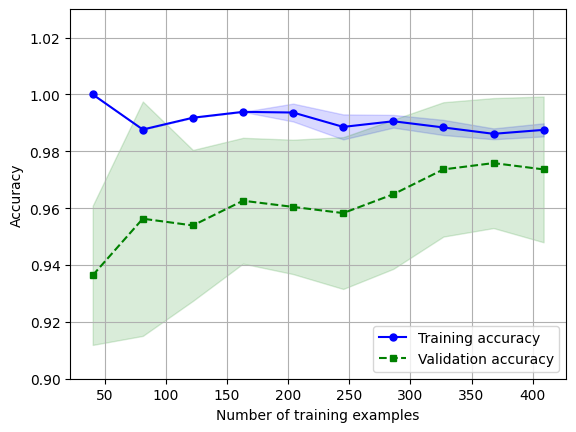

In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        l1_ratio=0,
        max_iter=10000
    )
)
train_sizes, train_scores, test_scores =\
    learning_curve(estimator=pipe_lr,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(
            0.1, 1.0, 10),
        cv=10,
        n_jobs=-1
    )
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
    color='blue', marker='o',
    markersize=5, label='Training accuracy'
)
plt.fill_between(train_sizes,
    train_mean + train_std,
    train_mean - train_std,
    alpha=0.15, color='blue'
)
plt.plot(train_sizes, test_mean,
    color='green', linestyle='--',
    marker='s', markersize=5,
    label='Validation accuracy'
)
plt.fill_between(train_sizes,
    test_mean + test_std,
    test_mean - test_std,
    alpha=0.15, color='green'
)
plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.9, 1.03])
plt.show()

### Validation curves

Validation curves are a useful tool for improving the performance of a model by addressing issues such as overfitting or underfitting. Validation curves are related to learning curves, but instead of plotting the training and test accuracies as functions of the sample size, we vary the values of the model parameters

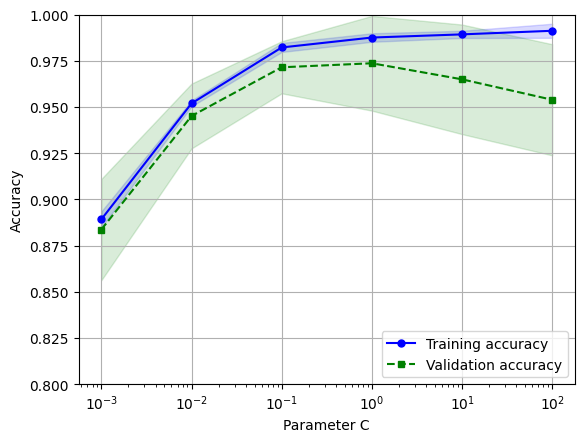

In [6]:
from sklearn.model_selection import validation_curve

pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        l1_ratio=0,
        max_iter=10000
    )
)
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
    estimator=pipe_lr,
    X=X_train,
    y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=10
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.plot(param_range, train_mean,
    color='blue', marker='o',
    markersize=5, label='Training accuracy')
plt.fill_between(param_range, train_mean + train_std,
    train_mean - train_std, alpha=0.15,
    color='blue')
plt.plot(param_range, test_mean,
    color='green', linestyle='--',
    marker='s', markersize=5,
    label='Validation accuracy')
plt.fill_between(param_range,
    test_mean + test_std,
    test_mean - test_std,
    alpha=0.15, color='green')
plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.show()

## Fine-tuning machine learning models

In machine learning, we have two types of parameters: those that are learned from the training data, for example, the weights in logistic regression, and the parameters of a learning algorithm that are optimized separately. The latter are the tuning parameters (or hyperparameters) of a model, for example, the regularization parameter in logistic regression or the maximum depth parameter of a decision tree.

### Tuning hyperparameters via grid search

* **The Concept:** Grid Search is an exhaustive, brute-force search technique used to find the absolute best combination of hyperparameters for a machine learning model to maximize its predictive performance.
* **How it Works:** You define a "parameter grid" (usually a dictionary) specifying the exact hyperparameters you want to tune and a list of values to test for each. The `GridSearchCV` module then systematically trains and evaluates the model using **every single possible combination** of those values.
* **Built-in Cross-Validation:** To guarantee that the performance metrics are reliable and not overfitted to a specific data split, scikit-learn's Grid Search automatically performs $k$-fold cross-validation internally for *each* parameter combination it tests. 
* **The Final Output:** After testing all combinations across all folds, the algorithm identifies the specific set of parameters that yielded the highest average validation score. By default, it will then automatically retrain (refit) your model on the entire training dataset using those optimal, fine-tuned settings so it is ready to make predictions.

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1))
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
param_grid = [
    {
        'svc__C': param_range,
        'svc__kernel': ['linear']
    },
    {
        'svc__C': param_range,
        'svc__gamma': param_range,
        'svc__kernel': ['rbf']
    }
]
gs = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=10,
    refit=True,
    n_jobs=-1)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)
print(f'Test accuracy: {gs.score(X_test, y_test):.3f}')


0.9758454106280192
{'svc__C': 10.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
Test accuracy: 0.982


### Exploring hyperparameter configurations more widely with randomized search

* **The Concept:** Unlike Grid Search, which exhaustively tests every single possible combination, Randomized Search evaluates a randomly selected subset of hyperparameter combinations from a defined search space over a fixed number of iterations.
* **How it Works:** Instead of only providing discrete lists of values, you can provide statistical distributions (such as uniform or log-uniform distributions) for continuous hyperparameters. The `RandomizedSearchCV` algorithm then randomly samples values from these distributions for a specified number of tries (controlled by the `n_iter` parameter).
* **The Main Advantage:** It is significantly more computationally efficient than Grid Search. By not forcing the algorithm to evaluate every minor, unimportant parameter combination in a rigid grid, it can explore a much larger, more diverse parameter space in a fraction of the time, often finding an equally good or even better model.
* **Built-in Features:** Just like its exhaustive counterpart, it internally utilizes $k$-fold cross-validation to reliably evaluate each random combination, and it automatically refits the final model with the best discovered parameters so it is ready for immediate predictions.

In [8]:
from sklearn.model_selection import RandomizedSearchCV
import scipy

param_range = scipy.stats.loguniform(0.0001, 1000.0)
pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1)
)
param_grid = [
    {
        'svc__C': param_range,
        'svc__kernel': ['linear']
    },
    {
        'svc__C': param_range,
        'svc__gamma': param_range,
        'svc__kernel': ['rbf']
    }
]
rs = RandomizedSearchCV(
    estimator=pipe_svc,
    param_distributions=param_grid,
    scoring='accuracy',
    refit=True,
    n_iter=20,
    cv=10,
    random_state=1,
    n_jobs=-1
)
rs = rs.fit(X_train, y_train)
print(rs.best_score_)
print(rs.best_params_)

0.9758454106280192
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


### More resource-efficient hyperparameter search with successive halving

**The Core Logic:** Instead of evaluating every single model configuration on the entire dataset from the start, Successive Halving acts as a survival tournament. It quickly weeds out poor-performing models using a small fraction of the data, reserving the heavy computational power strictly for the most promising candidates.

To understand exactly how the Successive Halving algorithm works under the hood, you only need to master these three specific parameters. Think of them as the strict rules of a survival tournament:

* **`n_candidates` (The Starting Pool):** This is the total number of different hyperparameter combinations that enter the competition at the very beginning. It represents every possible setup you want to test.
* **`resource` (The Budget):** This is the actual currency you are rationing during the tournament. By default in scikit-learn, this is the amount of training data (`n_samples`). However, for ensemble models like Random Forests, you can change this resource to be the number of trees (`n_estimators`).
* **`factor` (The Elimination Rate):** This single number controls both who survives and how the budget grows. If `factor = 3` (the standard default), two things happen at the end of every round: 
    1. Only the top **1/3** of the candidates survive to the next round (the rest are discarded).
    2. The surviving candidates are rewarded with **3 times** more `resource` for their next evaluation.

**The Main Advantage:** It drastically optimizes training time. By rapidly discarding weak configurations when it is mathematically cheap to do so, it allows you to explore a massive hyperparameter space much faster than a standard Grid or Randomized Search.

In [9]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

param_range = scipy.stats.loguniform(0.0001, 1000.0)
pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1)
)
param_grid = [
    {
        'svc__C': param_range,
        'svc__kernel': ['linear']
    },
    {
        'svc__C': param_range,
        'svc__gamma': param_range,
        'svc__kernel': ['rbf']
    }
]

hs = HalvingRandomSearchCV(
    pipe_svc,
    param_distributions=param_grid,
    n_candidates='exhaust',
    resource='n_samples',
    factor=1.5,
    random_state=1,
    n_jobs=-1
)
hs = hs.fit(X_train, y_train)

print(hs.best_score_)
print(f'Train accuracy: {hs.score(X_train, y_train):.3f}')
print(f'Test accuracy: {hs.score(X_test, y_test):.3f}')
print(hs.best_params_)

0.973529411764706
Train accuracy: 0.980
Test accuracy: 0.982
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


### Nested Cross-Validation to estimates the generalization performance of the model properly


**The Core Problem (Optimization Bias):** If we use standard Cross-Validation along with Grid Search to tune hyperparameters, the final performance metric is optimistically biased. Because the algorithm repeatedly evaluates itself on the validation folds to select the "best" parameters, information leaks. To prevent this, **Nested Cross-Validation** uses two strictly separated loops.

#### 1. The Initial Split (The Vault)
* **Objective:** To lock away a portion of the data that the hyperparameter tuning and model selection processes will absolutely never see until the very end.
* **Process:** We split the entire dataset into an original training set $(X_{train\_orig}, y_{train\_orig})$ and an original test set $(X_{test\_orig}, y_{test\_orig})$. 

#### 2. The Outer Loop (Error Estimation)
* **Objective:** To estimate the true generalization performance of our *entire modeling strategy* (including the hyperparameter search process), rather than evaluating a single specific model.
* **Process:** We perform a $k$-fold split (let's call it $k_{outer}$) strictly on $(X_{train\_orig}, y_{train\_orig})$. 
* **Variables:** For each iteration $i$, we obtain a training subset $(X_{train\_outer}^{(i)}, y_{train\_outer}^{(i)})$ and a test subset $(X_{test\_outer}^{(i)}, y_{test\_outer}^{(i)})$.

#### 3. The Inner Loop (Hyperparameter Tuning)
* **Objective:** To act as an isolated environment where the algorithm can optimize parameters blindly, without ever observing the outer test fold. 
* **Process:** For every iteration of the outer loop, we take the training subset $(X_{train\_outer}^{(i)}, y_{train\_outer}^{(i)})$ and perform *another* cross-validation split (e.g., $k_{inner}$ folds). Grid Search or Randomized Search operates exclusively within this inner loop.
* **Result:** This loop outputs the best hyperparameter configuration for the current outer iteration.

#### 4. The Iterative Evaluation
* **Objective:** To evaluate the optimal configuration found by the inner loop on unseen data.
* **Process:** The best model from the inner loop is trained on the full $(X_{train\_outer}^{(i)}, y_{train\_outer}^{(i)})$ and then evaluated on the untouched outer test fold $(X_{test\_outer}^{(i)}, y_{test\_outer}^{(i)})$. 

#### 5. The Unbiased Performance Metric
* **Objective:** To calculate the final, honest estimate of how the model will perform in the real world.
* **Process:** After the outer loop finishes all $k_{outer}$ iterations, we average the performance metrics. 
* **Equation:** The expected cross-validation error $E_{cv}$ is:
    $$E_{cv} = \frac{1}{k_{outer}} \sum_{i=1}^{k_{outer}} E_{i}$$
    *(Where $E_{i}$ is the evaluation metric from the $i$-th outer test fold).*

#### 6. Building the Final Production Model
* **Objective:** To build the ultimate model using all available training data now that we trust our strategy.
* **Process:** We discard all the temporary models generated in the nested loops. We take the full $(X_{train\_orig}, y_{train\_orig})$ and run a standard Grid Search over the entire set to find the definitive best parameters. We train the final model on 100% of $(X_{train\_orig}, y_{train\_orig})$.
* **The Final Verification:** We evaluate this production model on the highly protected $(X_{test\_orig}, y_{test\_orig})$. If the score closely matches our $E_{cv}$, we have mathematically proven that our model is robust and free of data leakage.

![Esquema de nested cross validation](../docs/images/nested-crsos-validatoin.png "Esquema de nested cross validation")

## Performance evaluation metrics

### Confusion matrix

**Definition:** A confusion matrix is a specific table layout that allows visualization of the performance of a supervised classification algorithm. It directly compares the *actual* target values in your dataset with the values *predicted* by your machine learning model.

**The Four Outcomes (in Binary Classification):**
* **True Positives (TP):** The model predicted the positive class, and the actual class was indeed positive (A correct detection).
* **True Negatives (TN):** The model predicted the negative class, and the actual class was indeed negative (A correct rejection).
* **False Positives (FP) / Type I Error:** The model predicted the positive class, but the actual class was negative (A false alarm).
* **False Negatives (FN) / Type II Error:** The model predicted the negative class, but the actual class was positive (A missed detection).

**Why it is Important:** It goes far beyond simple accuracy by showing you exactly *how* your classification model is getting confused. By breaking down the predictions into these four distinct categories, it provides the foundational numbers required to calculate all the advanced performance metrics (such as Precision, Recall, F1 Score, and MCC).

[[40  2]
 [ 0 72]]


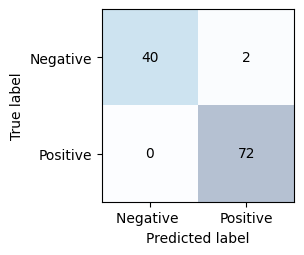

In [19]:
from sklearn.metrics import confusion_matrix
# By definition a confusion matrix C is such that C[i, j] is equal to the number 
# of observations known to be in group i and predicted to be in group j.
#
# Thus in binary classification:
# tn = C[0, 0]  # Count of True Negatives
# fn = C[1, 0]  # Count of False Negatives
# tp = C[1, 1]  # Count of True Positives
# fp = C[0, 1]  # Count of False Positives

pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1)
)
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_test, y_pred)
print(confmat)

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_ticks(ticks=[0, 1], labels=['Negative ','Positive'])
ax.yaxis.set_ticks(ticks=[0, 1], labels=['Negative','Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

### Prediction Error (ERR)

* **Definition:** Represents the proportion of all predictions that were misclassified by the model. It is the sum of all false predictions divided by the total number of predictions.
* **Equation:**
  $$ERR = \frac{FP + FN}{FP + FN + TP + TN}$$
* **Pros:** Provides a quick, high-level overview of the model's overall mistake rate.
* **Cons:** Does not distinguish between the types of errors (False Positives vs. False Negatives). This is problematic if one type of error carries a significantly higher real-world cost than the other.

### Accuracy (ACC)

* **Definition:** The complement of the prediction error. It quantifies the proportion of correct predictions (both true positives and true negatives) out of all the predictions made.
* **Equation:**
  $$ACC = \frac{TP + TN}{FP + FN + TP + TN} = 1 - ERR$$
* **Pros:** The most intuitive, easy-to-understand metric for measuring general performance.
* **Cons:** Can be highly misleading when dealing with imbalanced datasets. For example, if 99% of your data belongs to the negative class, a model that simply guesses "negative" every single time will achieve 99% accuracy while actually learning nothing.

In [16]:
from sklearn.metrics import accuracy_score
acc_score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc_score:.3f}')

Accuracy: 0.982


### Recall (REC) / True Positive Rate (TPR)

* **Definition:** Quantifies how many of the *actual* relevant records (the true positives) were successfully captured by the model.
* **Equation:**
  $$REC = TPR = \frac{TP}{P} = \frac{TP}{FN + TP}$$
* **Pros:** Crucial to optimize when the cost of missing a positive case is very high (e.g., ensuring a malignant tumor is not missed).
* **Cons:** Optimizing strictly for recall often makes the model aggressively predict everything as positive. This minimizes False Negatives but drastically inflates False Positives (e.g., diagnosing healthy patients with a tumor).

### Precision (PRE)

* **Definition:** Quantifies how many of the records *predicted* as relevant (the sum of true and false positives) were actually relevant.
* **Equation:**
  $$PRE = \frac{TP}{TP + FP}$$
* **Pros:** Ideal when you want to emphasize the "correctness" of your positive predictions because the cost of a False Positive is high (e.g., ensuring an important email is not misclassified as spam).
* **Cons:** Optimizing strictly for precision makes the model overly conservative. It will only predict positive when it is absolutely certain, meaning it will miss many actual positive cases (increasing False Negatives).

In [17]:
from sklearn.metrics import recall_score, precision_score
rec_score = recall_score(y_test, y_pred)
pre_score = precision_score(y_test, y_pred)
print(f'Recall score: {rec_score:.3f}')
print(f'precision score: {pre_score:.3f}')

Recall score: 1.000
precision score: 0.973


### F1 Score

* **Definition:** The harmonic mean of Precision and Recall. It is designed to balance the upsides and downsides of both metrics into a single number.
* **Equation:**
  $$F1 = 2 \frac{PRE \times REC}{PRE + REC}$$
* **Pros:** An excellent metric for evaluating models on imbalanced datasets, as the harmonic mean heavily penalizes the final score if either Precision or Recall drops too low.
* **Cons:** It completely ignores True Negatives (TN) in its calculation, meaning it does not fully reflect the model's performance on the negative class.

### Matthews Correlation Coefficient (MCC)

* **Definition:** A comprehensive measure that summarizes the entire confusion matrix into a single coefficient ranging from $-1$ (total disagreement) to $1$ (perfect prediction). It is especially popular in biological research.
* **Equation:**
  $$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$$
* **Pros:** Widely regarded as a superior metric to the F1 Score and Accuracy because it takes *all* four elements of the confusion matrix into account (including TN). It provides a reliable score even when the classes are heavily imbalanced.
* **Cons:** The mathematical output is slightly more abstract and harder to intuitively interpret for non-technical audiences compared to simple percentages like Accuracy.

In [18]:
from sklearn.metrics import f1_score, matthews_corrcoef
f1_score_ = f1_score(y_test, y_pred)
mcc_score = matthews_corrcoef(y_test, y_pred)
print(f'f1 score: {f1_score_:.3f}')
print(f'mcc score: {mcc_score:.3f}')

f1 score: 0.986
mcc score: 0.963


### Custom Scoring in GridSearchCV

**Changing the Default Metric:** By default, `GridSearchCV` evaluates models using *accuracy*. You can change this to other metrics (like Precision, Recall, or F1-score) by passing the desired metric's name to the `scoring` parameter.

**The "Positive Class" Rule:** Scikit-learn strictly assumes that your "positive class" is the one mathematically labeled as `1`.

**Creating Custom Scorers:** If your dataset uses a different label for the positive class (for example, `0` or `'malignant'`), you cannot just pass the metric name. You must use the `make_scorer` function to build a custom scoring object specifying your exact positive label, which you then pass into the `GridSearchCV` scoring parameter.

In [20]:
from sklearn.metrics import make_scorer
c_gamma_range = [0.01, 0.1, 1.0, 10.0]
param_grid = [
    {
        'svc__C': c_gamma_range,
        'svc__kernel': ['linear']
    },
    {
        'svc__C': c_gamma_range,
        'svc__gamma': c_gamma_range,
        'svc__kernel': ['rbf']
    }
]
scorer = make_scorer(f1_score, pos_label=0)
gs = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid,
    scoring=scorer,
    cv=10
)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9613883268295034
{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


### Dealing with class imbalance

**The Core Problem:** Machine learning algorithms minimize loss based on the *sum* of errors across all training examples. If a dataset is heavily imbalanced, the algorithm naturally develops a bias toward predicting the majority class, as this is the easiest mathematical path to minimize the overall training loss.

**Strategy 1: Algorithmic Penalization (Class Weights):** You can force the algorithm to pay more attention to the minority class by assigning a heavier penalty every time it misclassifies one of its instances.
* *Implementation:* In scikit-learn, you can easily apply this by setting the parameter `class_weight='balanced'` inside your chosen classifier.

**Strategy 2: Resampling Techniques:** You can manually alter the dataset's composition before training to balance the class proportions:
* **Upsampling:** Randomly duplicating existing examples from the minority class. Scikit-learn provides a `resample` function specifically to draw new samples with replacement.
* **Downsampling:** Randomly removing examples from the majority class to match the minority count.
* **Synthetic Data:** Generating entirely new, artificial examples for the minority class based on the patterns of existing data.

**The Golden Rule:** There is no universal "best" solution that works across all problem domains. The standard practice is to experiment with multiple strategies, evaluate them using robust metrics (like F1-Score or MCC instead of Accuracy), and choose the technique that performs best for your specific dataset.